In [2]:
import sys
sys.path.insert(0, './utils')
import pandas as pd
import numpy as np
from utils.measure import Measure, Styling, ClusterProcessor
from utils.read import DataProcessor
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.gridspec import GridSpec

In [2]:
def buildGlitchCoinc(datas, data_y, label_x, labels_y, ifo):
    """
        data_x: pd.DataFrame, it cointains Gravity Spy glitches
        data_y: pd.DataFrame, it cointains GravitySPy data
    """
    # Initialize an empty list to store rows
    df_list = []
    for data_x, label_y in zip(datas, labels_y):
        for x in range(len(data_x)):
            # Directly access the cluster time for the trigger at index x
            cluster_time_x = data_x.at[x, label_x]
            
            # Create a mask to filter data_y within the time window around cluster_time_x
            mask = (data_y[label_y] >= cluster_time_x - window) & (data_y[label_y] <= cluster_time_x + window)
            tmp_ = data_y[mask]
            
            if len(tmp_) > 0:
                # Create a row dictionary with the required data
                chis_snr1 = tmp_.at[tmp_.index[0], 'Chisq_max_'+ifo[2:]]/tmp_.at[tmp_.index[0], 'SNR_max_'+ifo[2:]]**2
                chis_snr2 = tmp_.at[tmp_.index[0], 'Chisq_max_'+ifo[:2]]/tmp_.at[tmp_.index[0], 'SNR_max_'+ifo[:2]]**2
                rank_stat = tmp_.at[tmp_.index[0], 'rank_stat_'+ifo]/((chis_snr1+chis_snr1)/2)
                row = {
                    'rank_stat': rank_stat, 
                    'SNR_max': tmp_.at[tmp_.index[0], 'SNR_max'+label_y[-3:]], 
                    'Chisq_max': tmp_.at[tmp_.index[0], 'Chisq_max'+label_y[-3:]], 
                    'SNR_GS': data_x.at[x, 'snr'], 
                    'confidence': data_x.at[x, 'confidence'], 
                    'label': data_x.at[x, 'label']
                }
                # Append the row dictionary to the list
                df_list.append(row)
    
    # Convert the list of dictionaries to a DataFrame
    df = pd.DataFrame(df_list)
    return df

def PlotGlitches(df):
    # Assuming df is already defined and structured correctly
    grouped = df.groupby('label')
    
    # Filter groups with more than 50 elements
    valid_groups = [(name, group) for name, group in grouped if len(group) > 0]
    num_groups = len(valid_groups)
    
    # Determine the grid size (e.g., 2 columns)
    cols = 2
    rows = (num_groups + cols - 1) // cols
    
    # Create a figure to hold all subplots
    fig = plt.figure(figsize=(15, 5 * rows), dpi=100)
    
    for idx, (name, group) in enumerate(valid_groups):
        print(name, len(group))
        
        # Create a GridSpec layout for the current group
        outer_grid = fig.add_gridspec(rows, cols, wspace=0.3, hspace=0.3)
        
        # Calculate the position for the current group
        row_idx = idx // cols
        col_idx = idx % cols
        
        # Create a nested GridSpec for the current group's subplots
        inner_grid = outer_grid[row_idx, col_idx].subgridspec(3, 3)
        
        ax1 = fig.add_subplot(inner_grid[0, 0:2])
        ax2 = fig.add_subplot(inner_grid[1:3, 0:2])
        ax3 = fig.add_subplot(inner_grid[1:3, 2])
        
        # Scatter plot
        ax2.scatter(group['Pinj'], group['confidence'], alpha=0.8, label=name, s=10, zorder=1)
        ax2.tick_params(axis='both', which='major', labelsize=14)
        ax2.set_xlabel(r'$P_{inj}$', fontsize=10)
        ax2.set_ylabel('Confidence $c_{GS}$', fontsize=10)
        
        # Histogram plot for Pinj
        sns.histplot(x=group['Pinj'], bins=25, kde=False, stat='probability', element='step', kde_kws={'cut': 3}, ax=ax1)
        ax1.relim()  # Recalculate the axis limits
        ax1.autoscale_view()
        
        # Histogram plot for confidence
        sns.histplot(y=group['confidence'], kde=False, bins=25, stat='probability', element='step', kde_kws={'cut': 3}, ax=ax3)
        
        
        ax3.relim()
        ax3.autoscale_view()
        
        ax3.set_xlabel('Probability density', fontsize=10)
        ax1.set_ylabel('Probability density', fontsize=10)
        ax1.tick_params(labelbottom=False)
        ax3.tick_params(labelleft=False)
        ax1.set_xlabel('')
        ax3.set_ylabel('')
        ax1.grid()
        ax2.grid()
        ax3.grid()
        ax2.legend()
    
    # Adjust layout to add space between subplots
    plt.tight_layout()
    plt.show()

def plotVars(var1, var2, var3, label1, label2, label3, name):
    fig = plt.figure(figsize=(8,8), dpi=100)
    gs=GridSpec(3,3) # 3 rows, 4 columns
    
    ax1=fig.add_subplot(gs[0:1,0:2])
    ax2=fig.add_subplot(gs[1:3, 0:2]) 
    ax3=fig.add_subplot(gs[1:3,2:3])
    
    scatter = ax2.scatter(var2, var1, c=var3, 
                 alpha =0.8, label=name, s=10,zorder=1)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    ax2.set_ylabel(label2, fontsize=14)
    ax2.set_xlabel(label1, fontsize=14)
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label(label3, rotation=270)
    ax2.set_yscale('log')
    ax2.set_xlim(0.1, 1000)
    plot = sns.histplot(x=var2, bins=100, kde=False, stat='probability',  kde_kws={'cut': 3}, ax=ax1)
    ax1.relim() # the axis limits need to be recalculated without the bars
    ax1.autoscale_view()
    ax3.set_yscale('log')
    
    plot2 = sns.histplot(y=var1,kde=False,bins=25, stat='probability', kde_kws={'cut': 3}, ax=ax3)
    ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax3.relim() 
    ax3.autoscale_view()
    
    ax3.set_xlabel('Probability density', fontsize=14)
    ax1.set_ylabel('Probability density', fontsize=14)
    ax1.tick_params(labelbottom=False)
    ax3.tick_params(labelleft=False)  
    ax1.set_xlabel('')
    ax3.set_ylabel('')
    ax1.grid(), ax2.grid(), ax3.grid()
    ax2.legend()
    plt.tight_layout()
    plt.show()


In [250]:
# Some variables
path_project = '/data/gravwav/lopezm/Projects/GlitchBank/'
path_inj = path_project+ 'runs/injections/'
path_zero_lag = path_project+'runs/zero_lag/'

path_glitches = 'runs/glitches/'
dp = DataProcessor(path_project + 'computational-aspects-of-machine-learning-project-3/output_new/tw0.05/predictions/', 
                   path_project + 'runs/zero_lag/', path_project + 'runs/injections')
file = 'GravitySpy_O3b.csv'

In [19]:
glt = pd.read_csv(path_project+path_glitches+file)
glt_H1, glt_L1, glt_V1 = glt[glt['ifo'] == 'H1'], glt[glt['ifo'] == 'L1'], glt[glt['ifo'] == 'V1']
dH1, dH1_c = dp.LoadZeroLag('h1', reset=True)
dL1, dL1_c = dp.LoadZeroLag('l1', reset=True)
dV1, dV1_c = dp.LoadZeroLag('v1', reset=True)

Air_Compressor 1034
Blip 701
Blip_Low_Frequency 4638
Chirp 17
Extremely_Loud 806
Fast_Scattering 2380
Helix 69
Koi_Fish 1402
Light_Modulation 210
Low_Frequency_Burst 38
Low_Frequency_Lines 19
No_Glitch 743
Paired_Doves 575
Power_Line 453
Repeating_Blips 466
Scattered_Light 2566
Scratchy 81
Tomte 3501
Violin_Mode 15
Whistle 76


/tmp/ipykernel_3440/1080452333.py:97: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


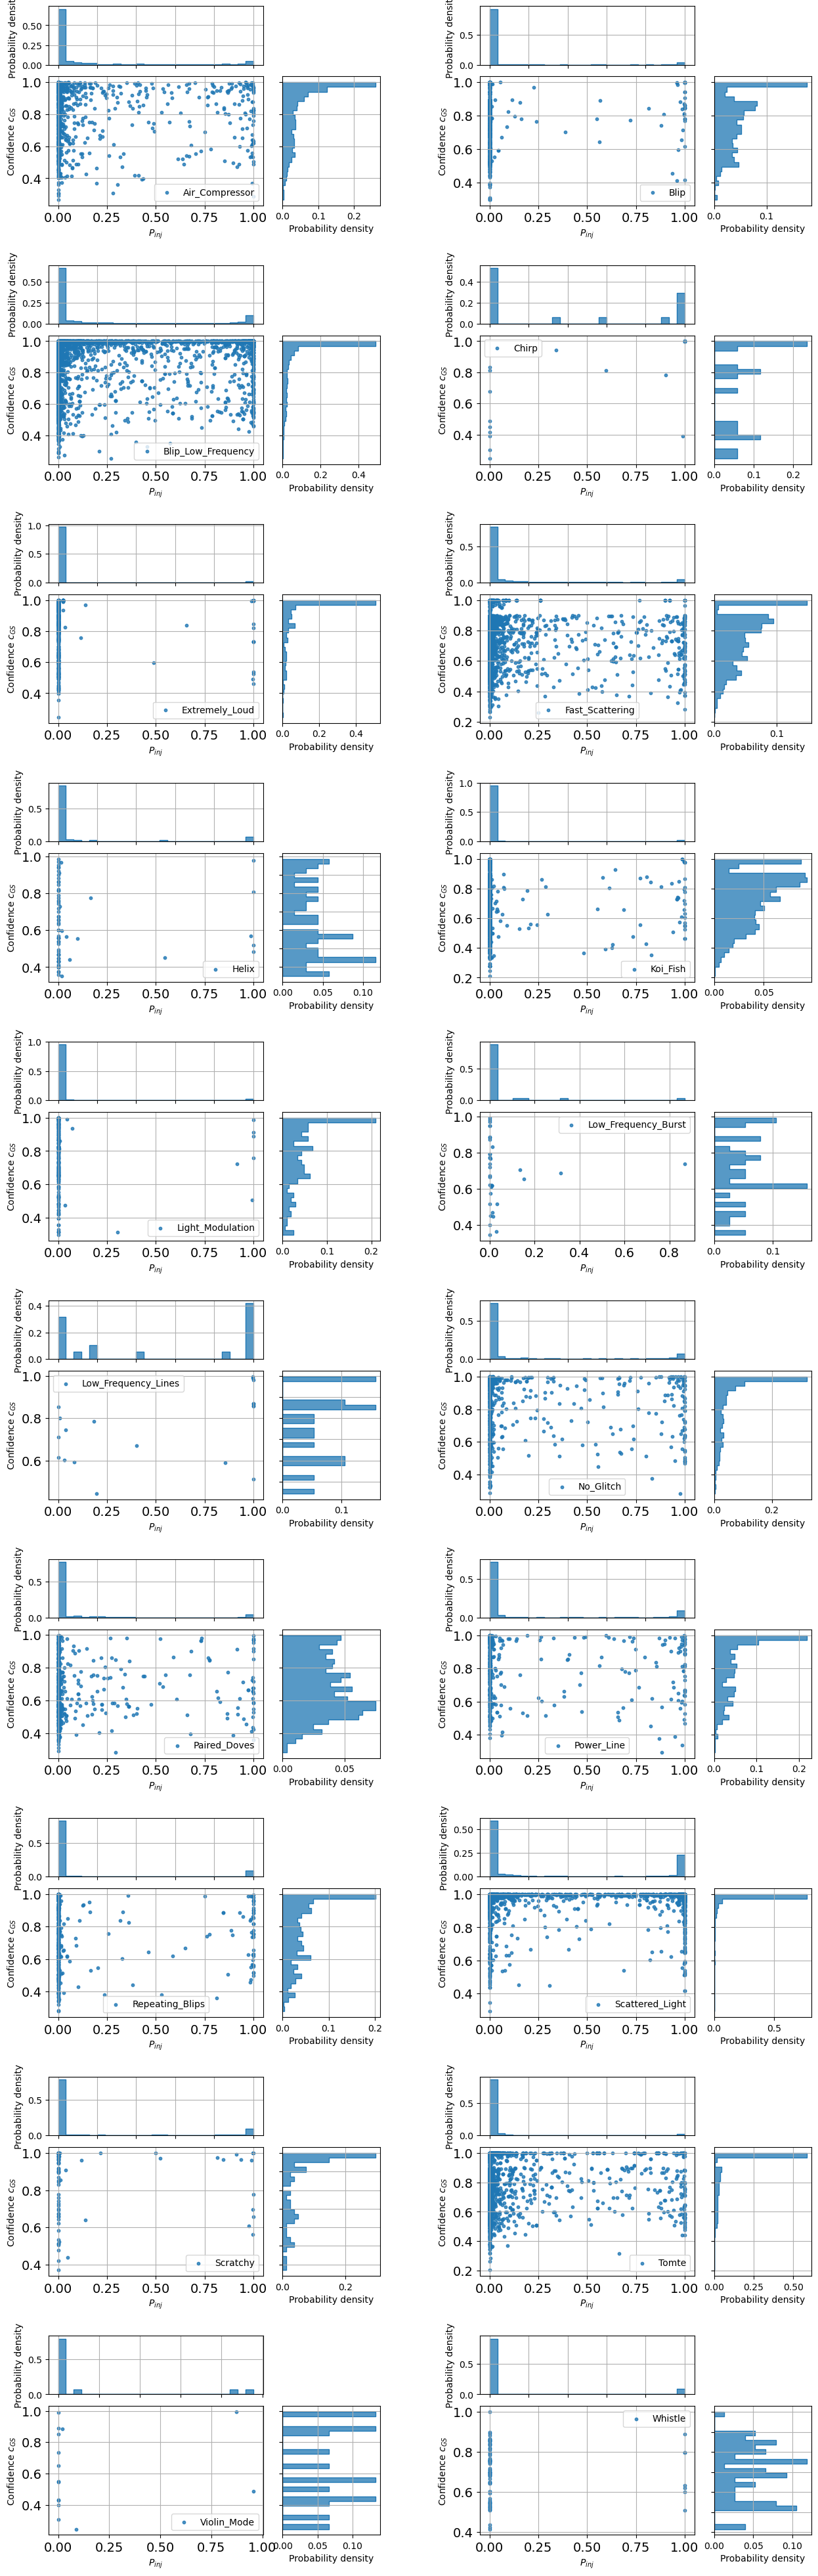

In [214]:
data_x, data_y =  glt_L1.copy(), dL1.copy(),
data_x = data_x.reset_index(drop=True)
label_x, label_y = 'GPStime', 'Cluster time'
window = 0.05 # this is the time window to select clusters
df = buildGlitchCoinc(data_x, data_y)
PlotGlitches(df)

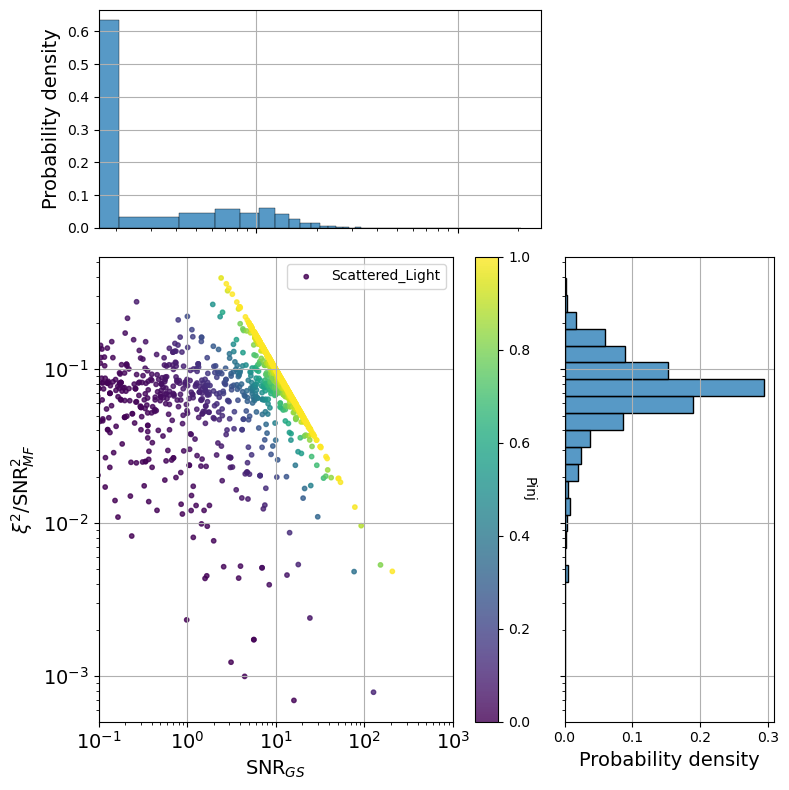

In [218]:
name = 'Scattered_Light'
tmp = grouped.get_group(name)
tmp = tmp.sort_values(by='Pinj')
var1 = tmp['Chisq_max'].values/tmp['SNR_max'].values**2
var2 = tmp['Pinj']/(tmp['Chisq_max'].values/tmp['SNR_max'].values**2)
var3 = tmp['Pinj']
label1, label2, label3 ='SNR$_{GS}$', r'$\xi^2/$SNR$^2_{MF}$', 'Pinj'
plotVars(var1, var2, var3, label1, label2, label3, name)


In [217]:
inj_hl = pd.read_pickle(path_inj + 'inj_coinc2_pred_hl.csv')

In [219]:
inj_hl.columns

Index(['injSNRH1', 'injSNRL1', 'injSNRV1', 'GPS', 'GPS ns', 'Mass1', 'Mass2',
       'Cluster ID', 'Distance', 'Cluster time', 'InsideH1', 'InsideL1',
       'InsideV1', 'InsideH1L1', 'InsideH1V1', 'InsideL1V1', 'InsideH1L1V1',
       'feature_H1', 'Class_H1', 'Num triggers_H1', 'Cluster ID_H1',
       'Cluster time_H1', 'SNR_max_H1', 'Chisq_max_H1', 'Mass_1_max_H1',
       'Mass_2_max_H1', 'feature_L1', 'Class_L1', 'Num triggers_L1',
       'Cluster ID_L1', 'Cluster time_L1', 'SNR_max_L1', 'Chisq_max_L1',
       'Mass_1_max_L1', 'Mass_2_max_L1', 'Prob_0_H1', 'Prob_1_H1', 'Prob_2_H1',
       'Prob_3_H1', 'Prob_4_H1', 'Prob_5_H1', 'Prob_6_H1', 'Pinj_H1',
       'rank_stat_H1', 'Prob_0_L1', 'Prob_1_L1', 'Prob_2_L1', 'Prob_3_L1',
       'Prob_4_L1', 'Prob_5_L1', 'Prob_6_L1', 'Pinj_L1', 'rank_stat_L1',
       'Pinj_H1L1', 'rank_stat_H1L1', 'injSNRH1L1'],
      dtype='object')

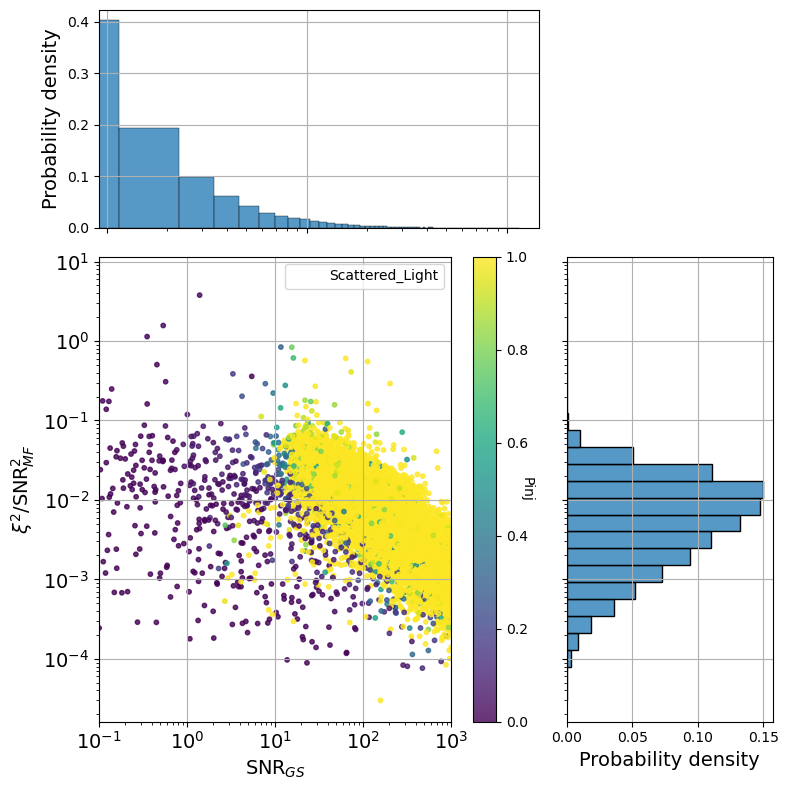

In [220]:
var1 = inj_hl['Chisq_max_H1'].values/inj_hl['SNR_max_L1'].values**2
var2 = inj_hl['Pinj_H1']/(inj_hl['Chisq_max_L1'].values/inj_hl['SNR_max_L1'].values**2)
var3 = inj_hl['Pinj_H1']
label1, label2, label3 ='SNR$_{GS}$', r'$\xi^2/$SNR$^2_{MF}$', 'Pinj'
plotVars(var1, var2, var3, label1, label2, label3, name)


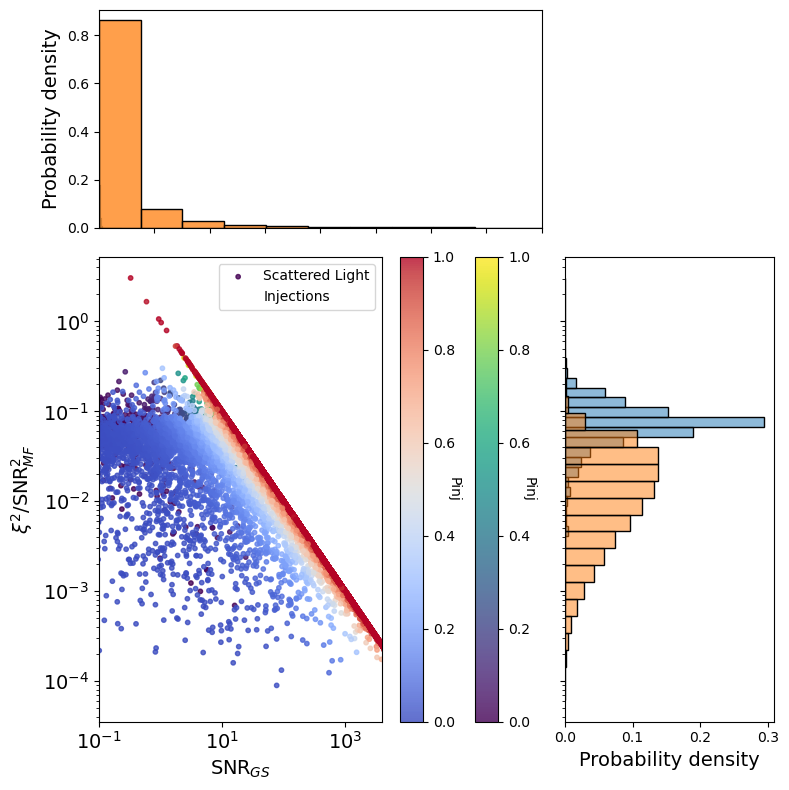

In [237]:


fig = plt.figure(figsize=(8,8), dpi=100)
gs=GridSpec(3,3) # 3 rows, 4 columns

ax1=fig.add_subplot(gs[0:1,0:2])
ax2=fig.add_subplot(gs[1:3, 0:2]) 
ax3=fig.add_subplot(gs[1:3,2:3])

for data, name, lab, cmap in zip([tmp, inj_hl], ['Scattered Light', 'Injections'], ['','_H1'], ['viridis', 'coolwarm']):

    var1 = data['Chisq_max'+lab].values/data['SNR_max'+lab].values**2
    var2 = data['Pinj'+lab]/(data['Chisq_max'+lab].values/data['SNR_max'+lab].values**2)
    var3 = data['Pinj'+lab]
    label1, label2, label3 ='SNR$_{GS}$', r'$\xi^2/$SNR$^2_{MF}$', 'Pinj'
    
    scatter = ax2.scatter(var2, var1, c=var3, 
                 alpha =0.8, label=name, s=10,zorder=1, cmap=cmap)
    ax2.tick_params(axis='both', which='major', labelsize=14)
    ax2.set_ylabel(label2, fontsize=14)
    ax2.set_xlabel(label1, fontsize=14)
    cbar = plt.colorbar(scatter, ax=ax2)
    cbar.set_label(label3, rotation=270)
    ax2.set_yscale('log')
    ax2.set_xlim(0.1, 4000)
    ax1.set_xlim(0.1, 4000)
    plot = sns.histplot(x=var2, bins=25, kde=False, stat='probability',  kde_kws={'cut': 3}, ax=ax1)
    ax1.relim() # the axis limits need to be recalculated without the bars
    ax1.autoscale_view()
    ax3.set_yscale('log')
    
    plot2 = sns.histplot(y=var1,kde=False,bins=25, stat='probability', kde_kws={'cut': 3}, ax=ax3, alpha=0.5)
    #ax1.set_xscale('log')
    ax2.set_xscale('log')
    ax3.relim() 
    ax3.autoscale_view()
    
    ax3.set_xlabel('Probability density', fontsize=14)
    ax1.set_ylabel('Probability density', fontsize=14)
    ax1.tick_params(labelbottom=False)
    ax3.tick_params(labelleft=False)  
    ax1.set_xlabel('')
    ax3.set_ylabel('')
    ax1.grid(), ax2.grid(), ax3.grid()
    ax2.legend()
plt.tight_layout()
plt.show()

In [271]:
ifo = 'H1L1'
file = f'triggers{ifo.replace("1", "")}_zero_lag_eq_match.csv'
zero_lag = pd.read_csv(path_zero_lag+file)
#glt_H1, glt_L1 = glt_H1.reset_index(drop=False), glt_L1.reset_index(drop=False)
df = buildGlitchCoinc([glt_H1, glt_L1], zero_lag, 'GPStime', ['Cluster time_H1', 'Cluster time_L1'], ifo)

In [272]:
df

,rank_stat,SNR_max,Chisq_max,SNR_GS,confidence,label
0,1.827217e+02,19.486256,80.649292,8206.208,1.000,Extremely_Loud
1,6.399336e-10,8.083550,1.826874,13.555,1.000,Repeating_Blips
2,7.432594e+02,7.819990,1.399893,7.997,1.000,Blip_Low_Frequency
3,5.609577e-09,7.189825,1.997519,9.752,1.000,Blip
4,-0.000000e+00,14.359032,5.846137,21.691,1.000,Repeating_Blips
...,...,...,...,...,...,...
760,2.131350e+01,8.196464,2.602577,7.569,0.418,Air_Compressor
761,3.932464e-02,13.667162,4.761342,9.584,0.383,No_Glitch
762,6.114868e-15,18.127792,16.620293,31.580,0.293,Koi_Fish
763,1.311577e-04,9.552383,4.697579,8.081,0.293,Blip_Low_Frequency


In [301]:
df.columns

Index(['rank_stat', 'SNR_max', 'Chisq_max', 'SNR_GS', 'confidence', 'label'], dtype='object')

(0.0, 300.0)

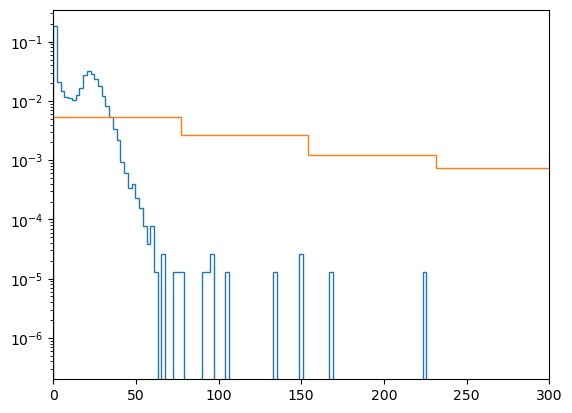

In [304]:
z1 = zero_lag['Pinj_L1']/(zero_lag['Chisq_max_L1'].values/zero_lag['SNR_max_L1'].values**2)
z2 = zero_lag['Pinj_H1']/(zero_lag['Chisq_max_H1'].values/zero_lag['SNR_max_H1'].values**2)
plt.hist(2/(1/z1+1/z2), bins=100, histtype='step', density=True)

i1 = inj_hl['Pinj_L1']/(inj_hl['Chisq_max_L1'].values/inj_hl['SNR_max_L1'].values**2)
i2 = inj_hl['Pinj_H1']/(inj_hl['Chisq_max_H1'].values/inj_hl['SNR_max_H1'].values**2)
plt.hist(2/(1/i1+1/i2), bins=100, histtype='step', density=True)
plt.yscale('log')
plt.xlim(0, 300)

In [307]:
inj_hl['Num triggers_H1'].min()

1.0

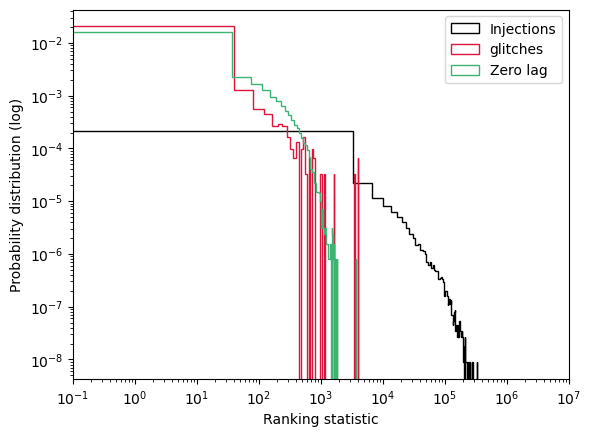

In [290]:
chi_snr1 = inj_hl['Chisq_max_L1'].values/inj_hl['SNR_max_L1'].values**2
chi_snr2 = inj_hl['Chisq_max_H1'].values/inj_hl['SNR_max_H1'].values**2

plt.hist(inj_hl['rank_stat_H1L1']/((chi_snr1+chi_snr2)/2), 
             density=True, bins=100, histtype='step', label='Injections', color='black')
plt.hist(df['rank_stat'], 
             density=True, bins=100, histtype='step', label='glitches', color='crimson')
plt.hist(zero_lag['rank_stat_H1L1']/((zero_lag['Chisq_max_L1'].values/zero_lag['SNR_max_L1'].values**2+zero_lag['Chisq_max_H1'].values/zero_lag['SNR_max_H1'].values**2)/2), 
             density=True, bins=100, histtype='step', label='Zero lag', color='mediumseagreen')

"""
grouped = df.groupby('label')
    
for name, data in grouped:
    plt.hist(data['rank_stat'], 
             density=True, bins=100, histtype='step', label=name)
"""
plt.xlim(0.1, 1e7)
plt.yscale('log')
plt.xscale('log')
plt.ylabel('Probability distribution (log)')
plt.xlabel('Ranking statistic')
plt.legend()

### ROC Curves

In [3]:
from utils.background import BackgroundFineTuner
from utils.read import RecoveryData, LogitToStat, DataProcessor, Merge
from FAR.utils.measure import Measure, Binning, CoincMass, SNRveto
from FAR.utils.utilities import remove_little_dogs
from FAR.utils.plot import Plotting as pl

ifos, t_search = 'H1L1', 0.5

path = '/data/gravwav/lopezm/Projects/GlitchBank/'
path_store = path + 'runs/background/results/'
timeslides_file = 'computational-aspects-of-machine-learning-project-3/FAR/timeslides_1132.9y.csv'
path_inj = '/data/gravwav/lopezm/Projects/GlitchBank/runs/injections/'
catalog = pd.read_pickle('/data/gravwav/lopezm/Projects/GlitchBank/runs/known_catalogs.csv')

merge, binning = Merge(path_store, path + timeslides_file), Binning() 

ifos = ['H1L1', 'H1V1', 'L1V1', 'H1L1V1']
colors = ['mediumorchid','cornflowerblue', 'hotpink', 'mediumseagreen']
t_searches = [0.561999936580416, 0.673738299086758, 0.6958418315575849, 0.5619617579908676]


In [4]:
def calculate_tprs_fprs(pos, neg, dt, ifos):

        tprs, fprs = [], []
        for d in dt:
            # We only consider post-GstLAL
            tp, p, _, _ = Measure.TPR(pos, ifos, p_star=d)
            tpr = tp / p * 100

            fpr = Measure.FPR(neg, ifos, p_star=d)
            tprs.append(tpr)
            fprs.append(fpr)
        return np.asarray(tprs), np.asarray(fprs)
     
def RankStat_1(data, ifos):
    if len(ifos) == 4:
        ifo1, ifo2 = ifos[:2], ifos[2:]
        rank_ifo1 = data['Pinj_'+ifo1]/(data['Chisq_max_'+ifo1]/ data['SNR_max_'+ifo1]**2)
        rank_ifo2 = data['Pinj_'+ifo2]/(data['Chisq_max_'+ifo2]/ data['SNR_max_'+ifo2]**2)
        rank_stat = 2/(1/rank_ifo1 + 1/rank_ifo2)
    if len(ifos) == 6:
        ifo1, ifo2, ifo3 = 'H1', 'L1', 'V1'
        rank_ifo1 = data['Pinj_'+ifo1]/(data['Chisq_max_'+ifo1]/ data['SNR_max_'+ifo1]**2)
        rank_ifo2 = data['Pinj_'+ifo2]/(data['Chisq_max_'+ifo2]/ data['SNR_max_'+ifo2]**2)
        rank_ifo3 = data['Pinj_'+ifo3]/(data['Chisq_max_'+ifo3]/ data['SNR_max_'+ifo3]**2)
        rank_stat = 3/(1/rank_ifo1 + 1/rank_ifo2)
    data['rank_stat_H1L1'] = rank_stat
    return data

def RankStat_1(data, ifos, formula):
    def calculate_rank_stat_1(data, ifos):
        #'P_{inj}/(\xi^2/SNR^2)'

        rank_values = [
            data[f'Pinj_{ifo}'] / (data[f'Chisq_max_{ifo}'] / data[f'SNR_max_{ifo}']**2)
            for ifo in ifos
        ]
        return len(ifos) / sum(1 / rank for rank in rank_values)

    def calculate_rank_stat_2(data, ifos):
        #'P_{inj}/(SNR^2)'

        rank_values = [
            data[f'Pinj_{ifo}'] / data[f'SNR_max_{ifo}']**2
            for ifo in ifos
        ]
        return len(ifos) / sum(1 / rank for rank in rank_values)
    
    def calculate_rank_stat_3(data, ifos):
        #'P_{inj} * (\xi^2/SNR^2)/e^(-SNR^2)'

        rank_values = [
            data[f'Pinj_{ifo}'] * (data[f'Chisq_max_{ifo}'] / data[f'SNR_max_{ifo}']**2) / np.exp(-data[f'SNR_max_{ifo}'])
            for ifo in ifos
        ]
        return len(ifos) / sum(1 / rank for rank in rank_values)

    if formula == 1:
        calculate_rank_stat = calculate_rank_stat_1
    elif formula == 2:
        calculate_rank_stat = calculate_rank_stat_2
    elif formula == 3:
        calculate_rank_stat = calculate_rank_stat_3
    else:
        raise ValueError("Unsupported formula")

    if len(ifos) == 4:
        ifos_subset = [ifos[:2], ifos[2:]]
        rank_stat_1 = calculate_rank_stat(data, ifos_subset)
        rank_stat_2 = calculate_rank_stat(data, ifos_subset)
        rank_stat = 2 / (1 / rank_stat_1 + 1 / rank_stat_2)
    elif len(ifos) == 6:
        ifos_subset = ['H1', 'L1', 'V1']
        rank_stat = calculate_rank_stat(data, ifos_subset)
    else:
        raise ValueError("Unsupported length of ifos")

    data['rank_stat_'+ifos] = rank_stat
    return data

H1L1
nan
nan
nan
nan


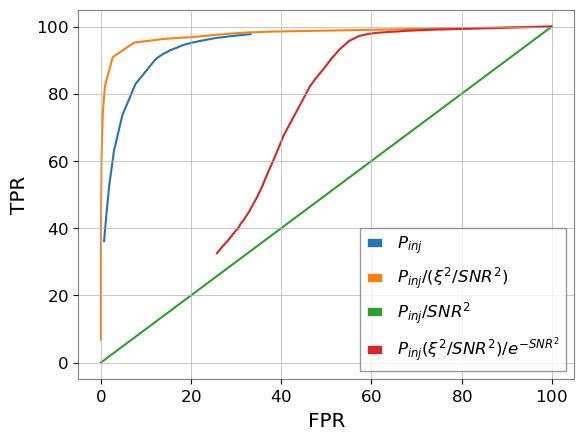

H1V1
nan
nan
nan
nan


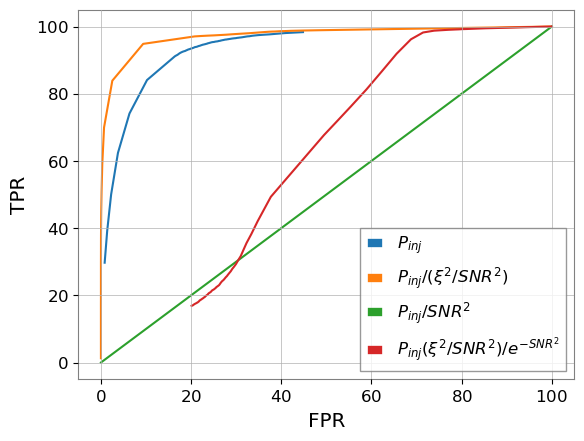

L1V1
nan
nan
nan
nan


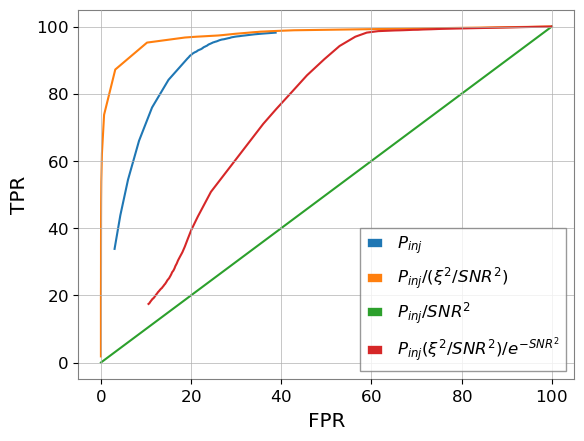

In [5]:
dt = np.arange(0.0, 0.9, 0.1).tolist() + np.arange(1, 10, 1).tolist() + np.arange(10, 1000, 10).tolist()

for ifo, t_search in zip(ifos[:-1], t_searches):
    print(ifo)
   
    t_bkg, neg = merge.mergeTriggers(ifo) # FIXME
    bft = BackgroundFineTuner(ifo, t_search, t_bkg)
    if len(ifo) == 4:
        pos = pd.read_pickle(path_inj + 'inj_coinc2_pred_'+ifo.lower().replace("1", "")+'.csv')
    if len(ifo) == 6:
        pos = pd.read_pickle(path_inj + 'inj_coinc3_pred_hlv.csv')
    tpr, fpr = bft.calculate_tprs_fprs(binning, pos, neg)
    plt.plot(fpr, tpr, label=r'$P_{inj}$')
    print(max(pos['rank_stat_'+ifo]))
    for formula, label in zip([1, 2, 3], [r'$P_{inj}/(\xi^2/SNR^2)$',
                                      r'$P_{inj}/SNR^2$',
                                      r'$P_{inj} (\xi^2/SNR^2)/e^{-SNR^2}$']):
        print(max(RankStat_1(pos, ifo, formula)['rank_stat_'+ifo]))
        tprs, fprs = calculate_tprs_fprs(RankStat_1(pos, ifo, formula),
                                         RankStat_1(neg, ifo, formula), dt, ifo)
        plt.plot(fprs, tprs, label=label)
    plt.xlabel('FPR'), plt.ylabel('TPR')
    plt.legend()
    plt.show()

H1L1
H1


,Pinj_H1,Pinj_L1,rank_stat_H1L1
9019,0.924467,0.000066,0.000133


L1


,Pinj_H1,Pinj_L1,rank_stat_H1L1
8884,0.000007,0.250204,0.000014


H1


...

,Pinj_H1,Pinj_L1,rank_stat_H1L1
8884,0.000007,0.250204,0.000014


L1


,Pinj_H1,Pinj_L1,rank_stat_H1L1
1187,0.035113,1.0,0.070255


L1


,Pinj_H1,Pinj_L1,rank_stat_H1L1
10186,0.001933,1.0,0.003866


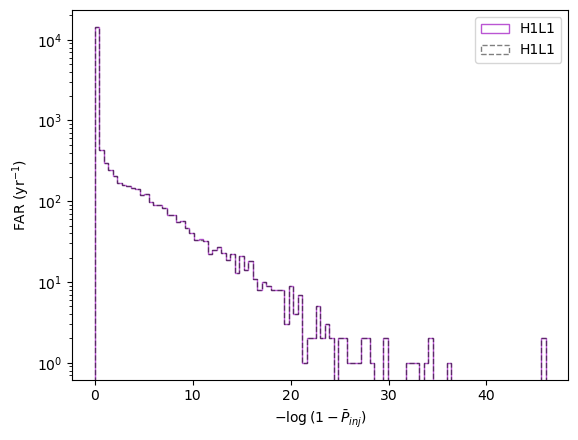

H1V1
H1


,Pinj_H1,Pinj_V1,rank_stat_H1V1
10359,0.95694,0.994697,3.707184


H1


,Pinj_H1,Pinj_V1,rank_stat_H1V1
10611,0.328322,0.999999,0.681893


H1


...

,Pinj_H1,Pinj_V1,rank_stat_H1V1
10118,0.999962,0.000087,0.000174


H1


,Pinj_H1,Pinj_V1,rank_stat_H1V1
10359,0.95694,0.994697,3.707184


H1


,Pinj_H1,Pinj_V1,rank_stat_H1V1
18823,1.0,0.14615,0.294407


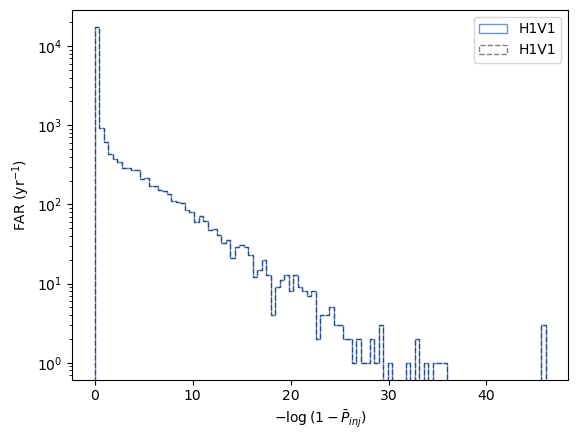

L1V1
L1


,Pinj_L1,Pinj_V1,rank_stat_L1V1
9084,1.0,0.994697,5.930041


L1


,Pinj_L1,Pinj_V1,rank_stat_L1V1
2129,1.0,0.988606,5.162111


L1


...

,Pinj_L1,Pinj_V1,rank_stat_L1V1
14522,1.0,0.066712,0.133622


L1


,Pinj_L1,Pinj_V1,rank_stat_L1V1
9084,1.0,0.994697,5.930041


L1


,Pinj_L1,Pinj_V1,rank_stat_L1V1
16435,1.0,0.14615,0.294407


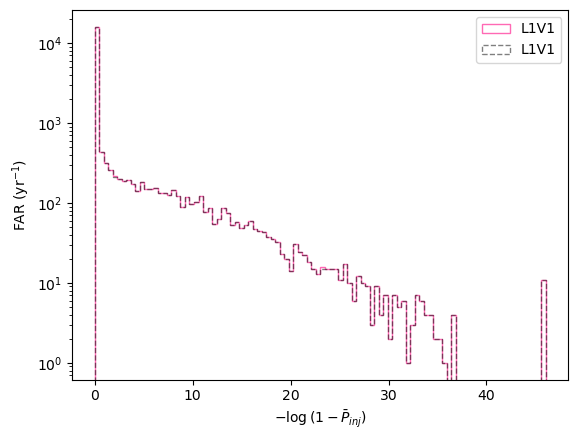

In [10]:
for ifo, color, t_search in zip(ifos[:-1], colors[:-1], t_searches):
    print(ifo)
    t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
    bkg_ = remove_little_dogs(catalog, bkg, ifo)
    plt.hist(bkg['rank_stat_'+ifo], bins=100, histtype='step',
             label=ifo, color=color)
    plt.hist(bkg_['rank_stat_'+ifo], bins=100, histtype='step',
             label=ifo, linestyle='--', color='black', alpha=0.5)
    
    plt.legend()
    plt.yscale('log')
    plt.xlabel(r'$- \log{(1-\bar{P}_{inj})}$')
    plt.ylabel('FAR (yr$^{-1})$')
    plt.show()

H1L1
1000.0


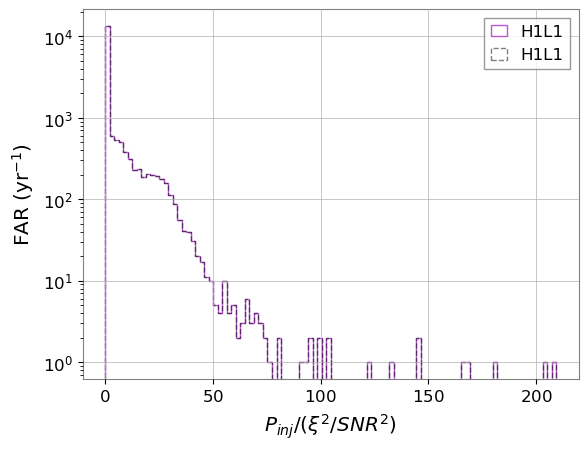

H1V1
1001.0


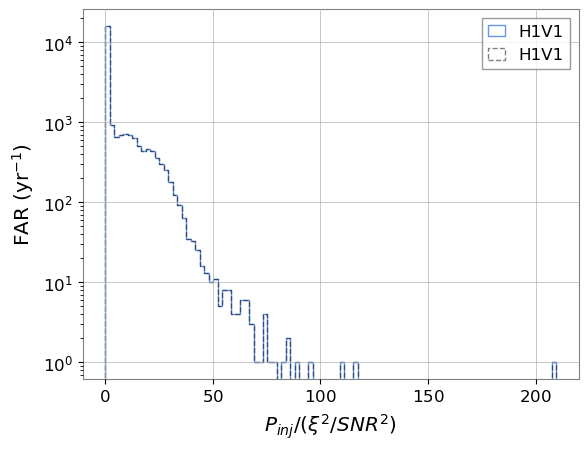

L1V1



KeyboardInterrupt



In [5]:
formula=1

for ifo, color, t_search in zip(ifos[:-1], colors[:-1], t_searches):
    print(ifo)
    t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
    print(t_bkg)
    bkg = RankStat_1(bkg, ifo, formula)
    bkg_ = remove_little_dogs(catalog, bkg, ifo)
    plt.hist(bkg['rank_stat_'+ifo], bins=100, histtype='step',
             label=ifo, color=color)
    plt.hist(bkg_['rank_stat_'+ifo], bins=100, histtype='step', linestyle='--', color='black', alpha=0.5)
    
    plt.legend()
    plt.yscale('log')
    plt.xlabel(r'$P_{inj}/(\xi^2/SNR^2)$')
    plt.ylabel('FAR (yr$^{-1})$')
    plt.show()

In [5]:
ifo = 'H1L1'
ifo1, ifo2 = ifo[:2], ifo[2:]
formula = 1
t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
bkg = RankStat_1(bkg, ifo, formula)
bkg = bkg.sort_values(by='rank_stat_' +ifo, ascending=False)

In [6]:
path_project = '/data/gravwav/lopezm/Projects/GlitchBank/'
path_glitches = 'runs/glitches/'

glt_o3a = pd.read_csv(path_project+path_glitches+'GravitySpy_O3a.csv')
glt_o3b = pd.read_csv(path_project+path_glitches+'GravitySpy_O3b.csv')

In [14]:
glt_o3a[(glt_o3a['GPStime'] >= bkg.iloc[i]['Cluster time old_'+ifo1] - 1) & (glt_o3a['GPStime'] <= bkg.iloc[i]['Cluster time old_'+ifo1] + 1)]

,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value


In [10]:
bkg[['Cluster time old_'+ifo1, 'Cluster time old_'+ifo2, 'SNR_max_'+ifo1, 'SNR_max_'+ifo2, 'Chisq_max_'+ifo1, 'Chisq_max_'+ifo2]].head(5)

,Cluster time old_H1,Cluster time old_L1,SNR_max_H1,SNR_max_L1,Chisq_max_H1,Chisq_max_L1
8371,1.242722e+09,1.242720e+09,15.933235,9.945289,1.712949,0.153026
13352,1.261551e+09,1.261547e+09,7.706801,18.059269,0.285914,1.621024
3586,1.266619e+09,1.266618e+09,10.549886,13.092710,0.769801,0.708497
8426,1.245747e+09,1.245745e+09,78.962807,45.739311,18.125063,18.867630
2856,1.257444e+09,1.257443e+09,13.192717,27.353329,0.879308,4.776289


/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '
/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


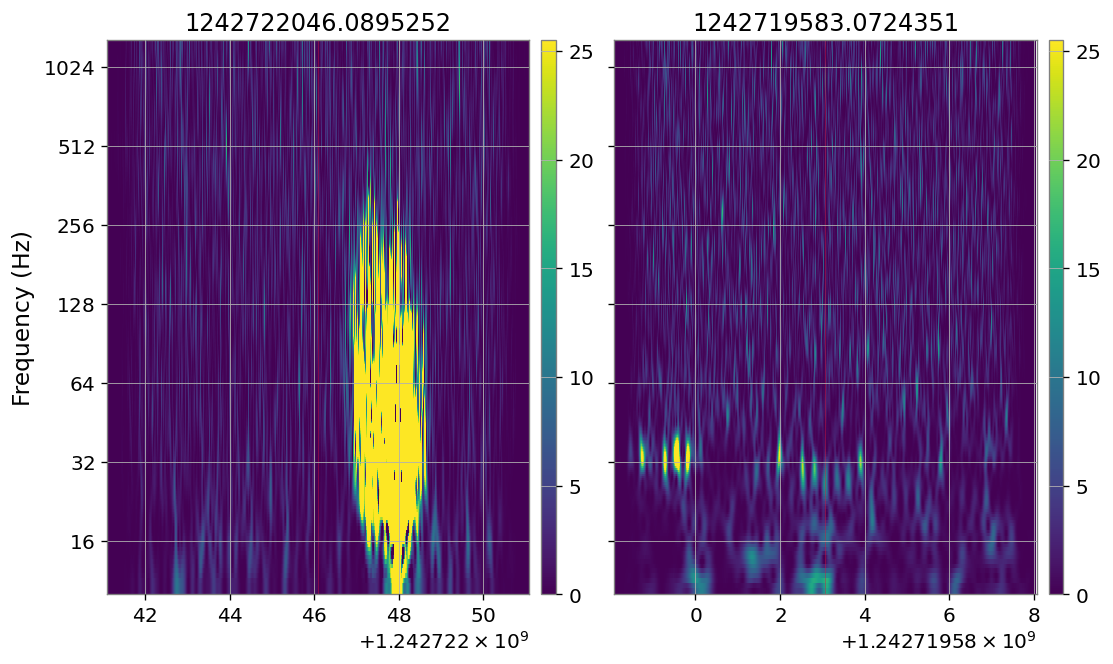

H1 1


,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
141020,1.261551e+09,27.09,9.346,2.360000e-22,2380.014,2.0,4722.197754,0.0,0.0,0.999,KNbZ7pcZgl,H1,Scattered_Light,https://ldas-jobs.ligo-wa.caltech.edu/~gravity...,45.255


L1 1


,GPStime,peakFreq,snr,amplitude,centralFreq,duration,bandwidth,chisq,chisqDof,confidence,id,ifo,label,imgUrl,Q-value
360899,1.261547e+09,24.264,17.925,4.320000e-22,3056.381,1.75,6092.762207,0.0,0.0,0.86,iuo23QxLGg,L1,Fast_Scattering,https://ldas-jobs.ligo-la.caltech.edu/~gravity...,11.314


/data/gravwav/lopezm/cmb_env/miniforge3/envs/tracks_env/lib/python3.9/site-packages/gwpy/signal/qtransform.py:124: UserWarning: upper frequency of 2048.00 is too high for the given Q range, resetting to 1291.05
  warnings.warn('upper frequency of %.2f is too high for the given '


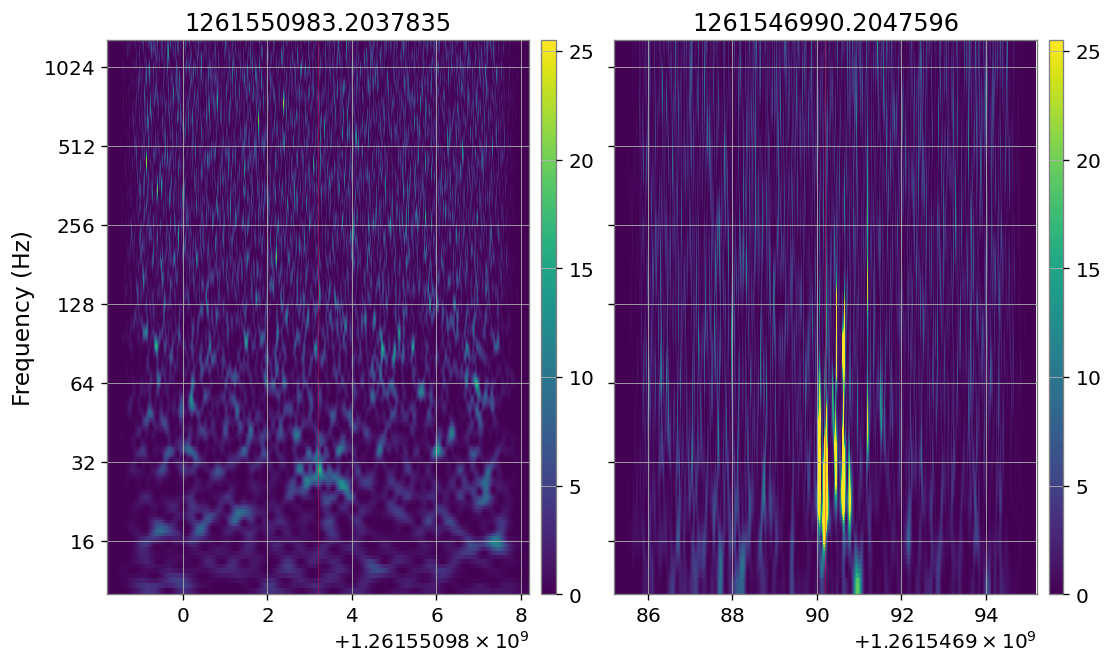

In [7]:
i = 0
for i in range(2):
    for k in [ifo1, ifo2]:
        t_star = bkg.iloc[i]['Cluster time old_'+k]

        tmp_o3a =  glt_o3a[(glt_o3a['GPStime'] >= t_star - 1) & (glt_o3a['GPStime'] <= t_star + 1)]
        tmp_o3b =  glt_o3b[(glt_o3b['GPStime'] >= t_star - 1) & (glt_o3b['GPStime'] <= t_star + 1)]
        if len(tmp_o3a) > 0:
            print(k, i)
            display(tmp_o3a)
        if len(tmp_o3b) > 0:
            print(k, i)
            display(tmp_o3b)
    pl.plotSpect2coinc(ifo1, ifo2, bkg.iloc[i]['Cluster time old_'+ifo1],
                    bkg.iloc[i]['Cluster time old_'+ifo2], tw=5)


In [19]:
def remove_little_dogs(catalog, bkg, ifo, offset = 1):
    ids = []
    for c in range(len(catalog)):
        t_star = catalog.iloc[c]['GPS']
        if len(ifo) == 4: 
            ifo1, ifo2 = ifo[:2], ifo[2:]
            ifo_list = [ifo1, ifo2]
        if len(ifo) == 6:
            ifo1, ifo2, ifo3 = ifo[:2], ifo[2:4], ifo[4:]
            ifo_list = [ifo1, ifo2, ifo3]

        for i in ifo_list:
            cond1 = (bkg['Cluster time old_' + i] >= t_star - offset)
            cond2 = (bkg['Cluster time old_' + i] <= t_star + offset)
            tmp = bkg[cond1 & cond2]
            if len(tmp)>0:
             # print(i)
             # display(tmp[['Pinj_'+ifo1, 'Pinj_'+ifo2, 'rank_stat_'+ifo]])
             ids.append(tmp.index.values[0])
    ids = np.unique(ids)
    return bkg.drop(ids)


H1L1
17763 17755 1000.0
H1V1
23701 23694 1001.0
L1V1
21204 21196 1000.0


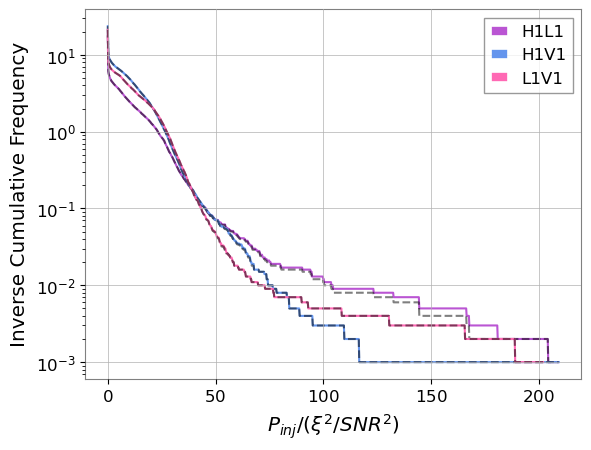

In [21]:
def plot_inverse_cumulative_histogram(data, bins=10):
    # Compute the histogram
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # Compute the cumulative sum of the counts in reverse order
    inverse_cumulative_counts = np.cumsum(counts[::-1])[::-1]

    return bin_edges, inverse_cumulative_counts

formula=1

for ifo, color, t_search in zip(ifos[:-1], colors[:-1], t_searches):
    print(ifo)
    t_bkg, bkg = merge.mergeTriggers(ifo) # FIXME
    bkg = RankStat_1(bkg, ifo, formula)
    bkg_ = remove_little_dogs(catalog, bkg, ifo, offset = 1)
    print(len(bkg), len(bkg_), t_bkg)

    b1, i1 = plot_inverse_cumulative_histogram(bkg['rank_stat_'+ifo], bins=1000)
    b2, i2 = plot_inverse_cumulative_histogram(bkg_['rank_stat_'+ifo], bins=1000)
    
    # Plot the inverse cumulative histogram
    plt.plot(b1[:-1], i1/t_bkg, color=color, label=ifo)
    plt.plot(b2[:-1], i2/t_bkg, alpha=0.5, linestyle='--', color='black')
    plt.xlabel(r'$P_{inj}/(\xi^2/SNR^2)$')
    plt.ylabel('Inverse Cumulative Frequency')
    
    plt.yscale('log')
    plt.legend()

